In [18]:
import kagglehub
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_prep import load_data, calculate_train_rul, normalize_data, apply_outlier_capping, create_sliding_windows

In [19]:
# Download latest version
base_path = kagglehub.dataset_download("bishals098/nasa-turbofan-engine-degradation-simulation")

print(f"Path to dataset files: {base_path}")

Path to dataset files: /home/mordicus/.cache/kagglehub/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/versions/1


In [20]:
# Convert the string path to a Path object
dataset_dir = Path(base_path)

# Define and verify required files
required_files = {
    "train": "train_FD001.txt",
    "test": "test_FD001.txt",
    "label": "RUL_FD001.txt"
}

paths = {}
for key, filename in required_files.items():
    file_path = dataset_dir / filename
    if not file_path.exists():
        raise FileNotFoundError(f"Required file {filename} not found in {dataset_dir}")
    paths[key] = file_path
    print(f"Verified: {filename} exists at {file_path}")

train_file = paths['train']
test_file = paths['test']
label_file = paths['label']

Verified: train_FD001.txt exists at /home/mordicus/.cache/kagglehub/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/versions/1/train_FD001.txt
Verified: test_FD001.txt exists at /home/mordicus/.cache/kagglehub/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/versions/1/test_FD001.txt
Verified: RUL_FD001.txt exists at /home/mordicus/.cache/kagglehub/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/versions/1/RUL_FD001.txt


In [21]:
# List all files in the directory
for file in dataset_dir.iterdir():
    print(file.name)

RUL_FD004.txt
train_FD002.txt
RUL_FD002.txt
train_FD004.txt
train_FD001.txt
readme.txt
Damage Propagation Modeling.pdf
test_FD003.txt
train_FD003.txt
test_FD002.txt
RUL_FD001.txt
RUL_FD003.txt
test_FD004.txt
test_FD001.txt


In [22]:
# Define file paths
train_file = dataset_dir / "train_FD001.txt"
test_file = dataset_dir / "test_FD001.txt"
label_file = dataset_dir / "RUL_FD001.txt"

print(f"Training file: {train_file}")
print(f"Test file: {test_file}")
print(f"Label file: {label_file}")

Training file: /home/mordicus/.cache/kagglehub/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/versions/1/train_FD001.txt
Test file: /home/mordicus/.cache/kagglehub/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/versions/1/test_FD001.txt
Label file: /home/mordicus/.cache/kagglehub/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/versions/1/RUL_FD001.txt


In [23]:
# Load and process data using functions from data_prep.py for EDA purposes only (no normalization/windowing)
train_df, test_df, label_df = load_data(base_path)

# Display basic information using the processed dataframes
print(f"Training data shape: {train_df.shape}")
print(f"Label data shape: {label_df.shape}")
print(f"Test data shape: {test_df.shape}")
print("\nTraining data head:")
print(train_df.head(1))
print("\nLabel data head:")
print(label_df.head(1))
print("\nTest data head:")
print(test_df.head(1))


Training data shape: (20631, 26)
Label data shape: (100, 1)
Test data shape: (13096, 26)

Training data head:
   unit_id  cycle  op_cond_1  op_cond_2  op_cond_3  sensor_1  sensor_2  \
0        1      1    -0.0007    -0.0004      100.0    518.67    641.82   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0    1589.7    1400.6     14.62  ...     521.66    2388.02    8138.62   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  
0     8.4195       0.03        392       2388      100.0      39.06     23.419  

[1 rows x 26 columns]

Label data head:
   RUL
0  112

Test data head:
   unit_id  cycle  op_cond_1  op_cond_2  op_cond_3  sensor_1  sensor_2  \
0        1      1     0.0023     0.0003      100.0    518.67    643.02   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1585.29   1398.21     14.62  ...     521.72    2388.03    8125.55   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor

In [24]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit_id    20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   op_cond_1  20631 non-null  float64
 3   op_cond_2  20631 non-null  float64
 4   op_cond_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor_16  20631 

In [25]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_cond_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_cond_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_cond_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [26]:
print('Train_df NUll Val: ',train_df.isnull().sum().sum())
print('Test_df NUll Val: ',test_df.isnull().sum().sum())

Train_df NUll Val:  0
Test_df NUll Val:  0


In [27]:
train_df.set_index('unit_id', inplace=True)

In [28]:
# Calculate RUL for training set as per original notebook intent before EDA checks
train_df = calculate_train_rul(train_df)

In [29]:
# Statistical Feature Selection using Correlation with RUL
correlations = train_df.corr()['RUL'].abs().sort_values(ascending=False)
print("\n--- Top 10 Least Informative Features (by absolute correlation with RUL) ---")
print(correlations.tail(10))


--- Top 10 Least Informative Features (by absolute correlation with RUL) ---
unit_id      0.078753
op_cond_1    0.003198
op_cond_2    0.001948
op_cond_3         NaN
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64


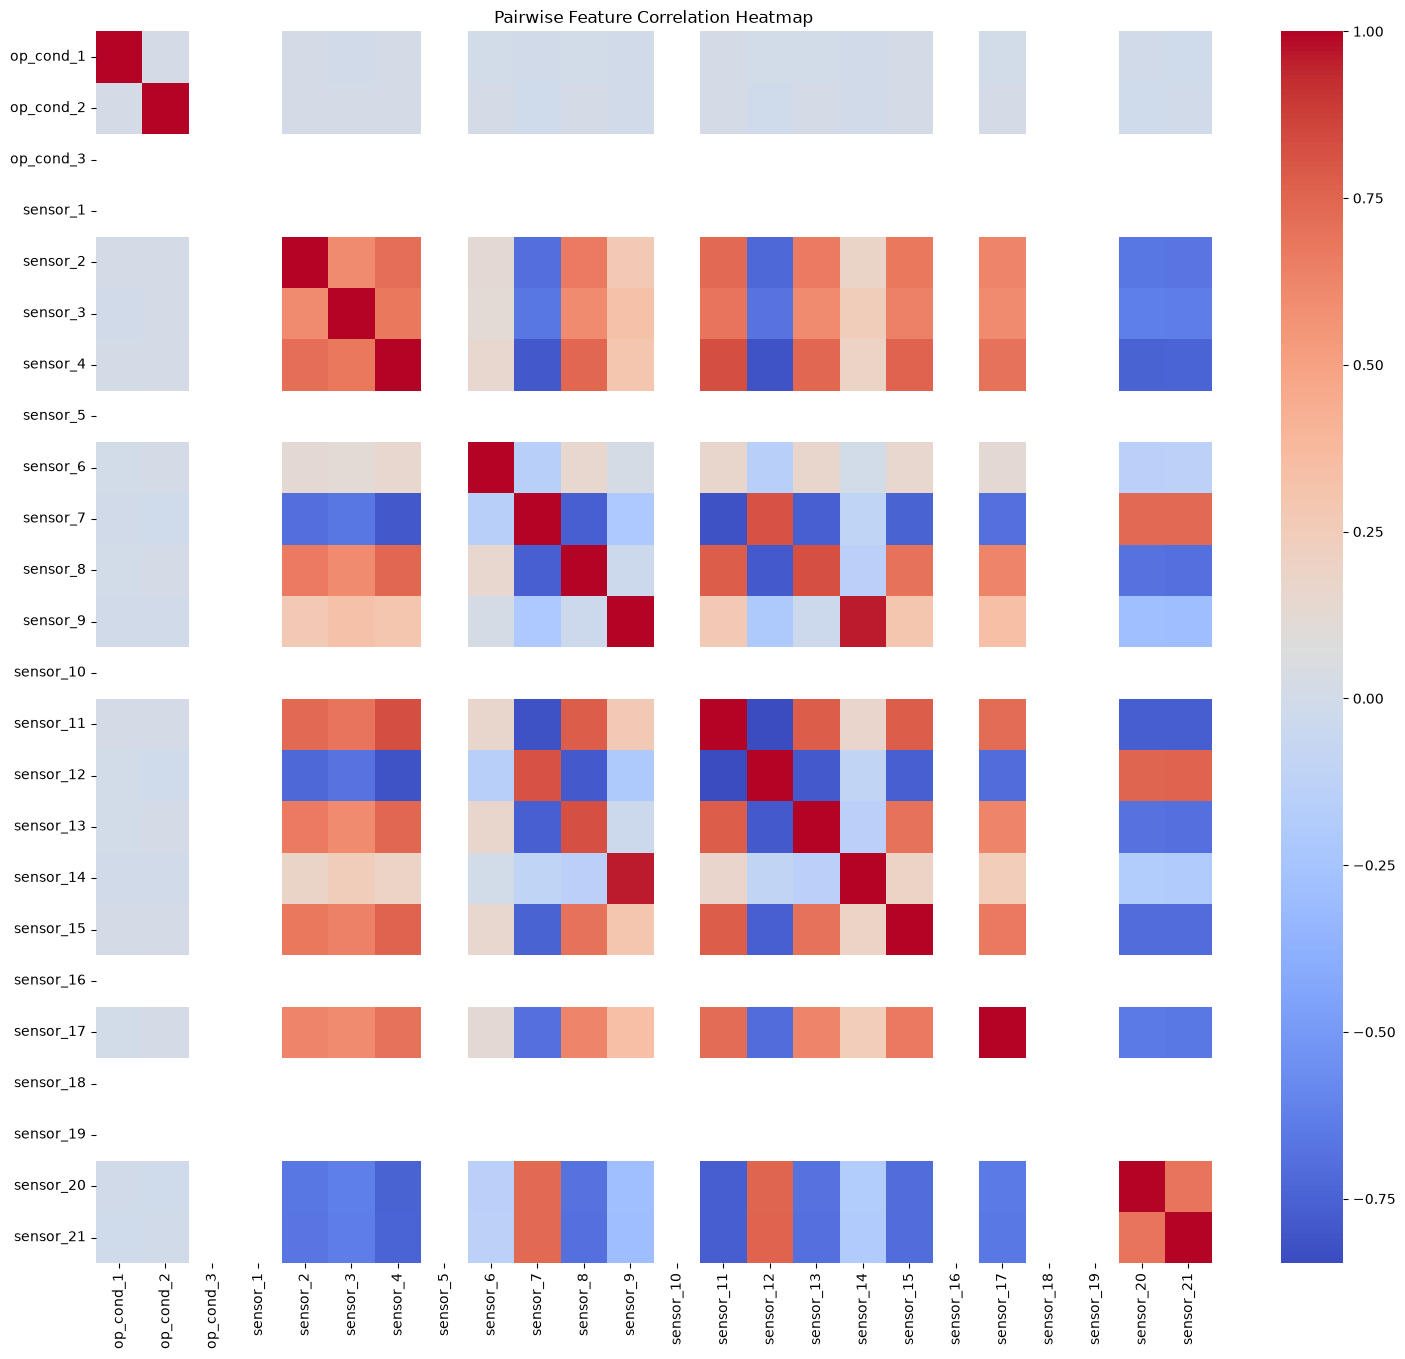

In [30]:
# Generate a heatmap to visualize pairwise correlations among all remaining features for multicollinearity insight.

# Select only feature columns (excluding 'RUL') from the processed train_df.
feature_cols = [col for col in train_df.columns if col != 'RUL' and col != 'unit_id' and col != 'cycle']  # Exclude 'RUL' and 'unit_id' from features
features_df = train_df[feature_cols]

# Calculate and plot the correlation matrix.
correlation_matrix = features_df.corr()

plt.figure(figsize=(18, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Pairwise Feature Correlation Heatmap')
plt.show()


In [31]:
# Drop least informative features based on correlation analysis
sensors_to_drop = ['op_cond_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
train_df.drop(columns=sensors_to_drop, inplace=True)
test_df.drop(columns=sensors_to_drop, inplace=True)

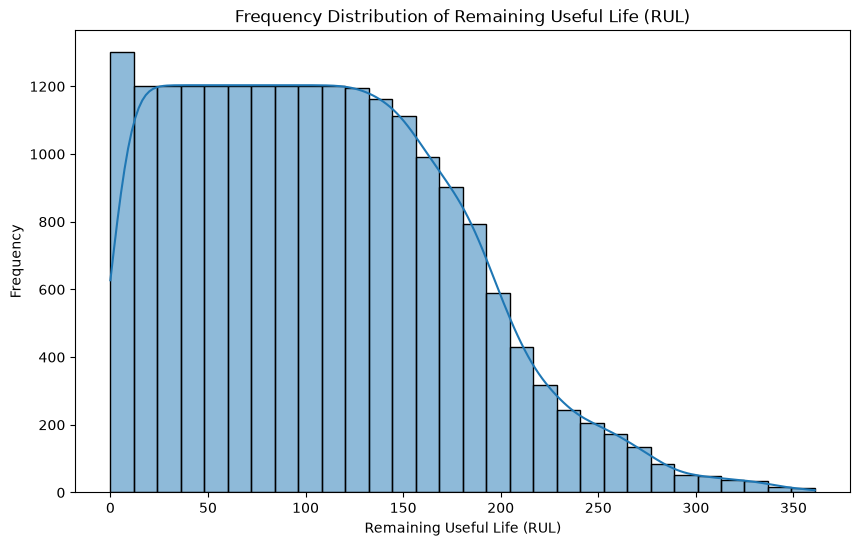

In [32]:
# Visualize the frequency distribution of Remaining Useful Life (RUL).
plt.figure(figsize=(10, 6))
sns.histplot(train_df['RUL'], bins=30, kde=True) # Assuming train_df is available and contains 'RUL' column 
plt.title('Frequency Distribution of Remaining Useful Life (RUL)')
plt.xlabel('Remaining Useful Life (RUL)')
plt.ylabel('Frequency')
plt.show()


The RUL distribution shows that the majority of engines have RUL of about 150 cycles or less with fewer extending towards 350 cycles. The spike at 0 cycles is because some sequences are shorter than the time window.

In [33]:
# Test for covariate shift between training and test datasets
report = {}
for col in train_df.drop(columns=['RUL']).columns:
    train_col = train_df[col]
    test_col = test_df[col]

    report[col] = {
        "Train Mean": train_col.mean(), #location shift
        "Test Mean": test_col.mean(),
        "Mean Difference": abs(train_col.mean() - test_col.mean()),

        "Train Std": train_col.std(), #scale shift
        "Test Std": test_col.std(),
        "Std Difference": abs(train_col.std() - test_col.std()),

        "Train Min": train_col.min(),
        "Test Min": test_col.min(),

        "Train Max": train_col.max(),
        "Test Max": test_col.max(),

        "Test Out of Train Range": ( #MinMax shift to detect the model extraplotation
            test_col.min() < train_col.min() or 
            test_col.max() > train_col.max()
        )
    }

simple_report_df = pd.DataFrame(report).T
simple_report_df

,Train Mean,Test Mean,Mean Difference,Train Std,Test Std,Std Difference,Train Min,Test Min,Train Max,Test Max,Test Out of Train Range
unit_id,51.506568,51.543907,0.037339,29.227633,28.289423,0.93821,1,1,100,100,False
cycle,108.807862,76.836515,31.971347,68.88099,53.057749,15.823241,1,1,362,303,False
op_cond_1,-0.000009,-0.000011,0.000002,0.002187,0.002203,0.000015,-0.0087,-0.0082,0.0087,0.0078,False
op_cond_2,0.000002,0.000004,0.000002,0.000293,0.000294,0.000001,-0.0006,-0.0006,0.0006,0.0007,True
sensor_2,642.680934,642.475088,0.205846,0.500053,0.400899,0.099154,641.21,641.13,644.53,644.3,True
sensor_3,1590.523119,1588.099204,2.423914,6.13115,5.003274,1.127876,1571.04,1569.04,1616.91,1607.55,True
sensor_4,1408.933782,1404.735362,4.19842,9.000605,6.688309,2.312295,1382.25,1384.39,1441.49,1433.36,False
sensor_6,21.609803,21.609701,0.000103,0.001389,0.001704,0.000315,21.6,21.6,21.61,21.61,False
sensor_7,553.367711,553.757523,0.389812,0.885092,0.681286,0.203806,549.85,550.88,556.06,555.84,False
sensor_8,2388.096652,2388.070964,0.025687,0.070985,0.057442,0.013544,2387.9,2387.89,2388.56,2388.3,True


In [ ]:
# Key Feature Distribution Analysis: Plot histograms and KDEs for several representative features to examine their individual distributions (skewness, modality).